In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv(r"C:\Users\HP\Downloads\Telco-Customer-Churn.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(df.shape)

(7043, 21)


In [4]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# Filling Missing Values

In [5]:
print((df["TotalCharges"] == ' ').sum())        #finding hidden missing values

11


In [6]:
df['TotalCharges'] = df['TotalCharges'].replace(' ',np.nan)   #replace them by nan
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])       
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_13180\440124478.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


# Remove Unnecessary Columns

In [7]:
df.drop('customerID',axis = 1,inplace=True)

# convert churn value into numeric 1,0

In [8]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

# Analysis by plot

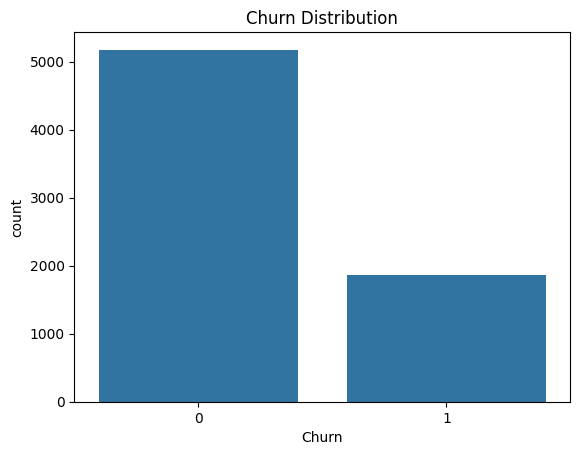

In [9]:
sns.countplot(x = 'Churn', data = df)
plt.title('Churn Distribution')
plt.show()
#its an highly imbalanced
#more customers stay than leave

# Correlation Heatmap

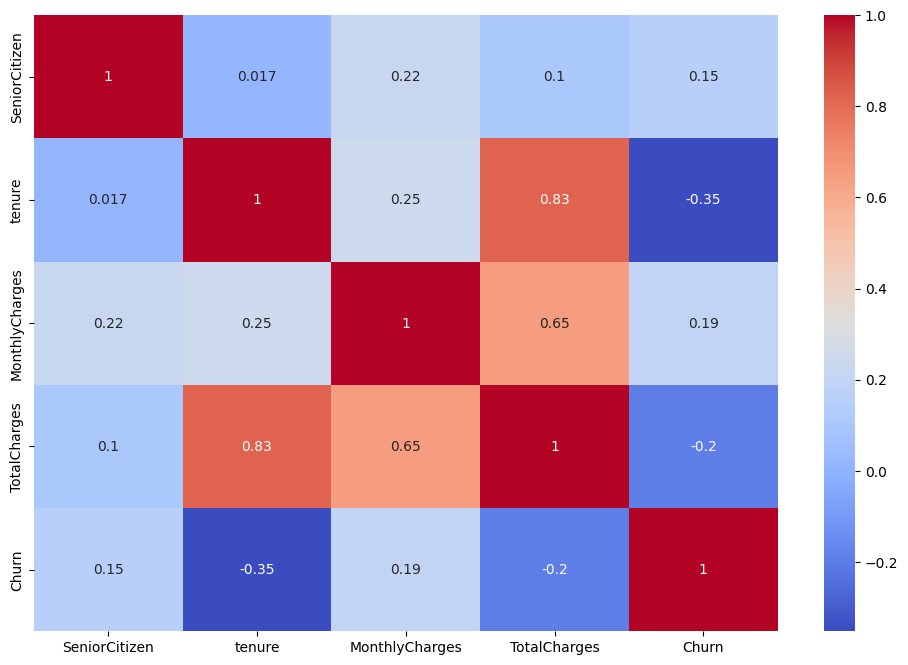

In [10]:
plt.figure(figsize = (12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap = 'coolwarm')
plt.show()

# Monthly Charges vs Churn

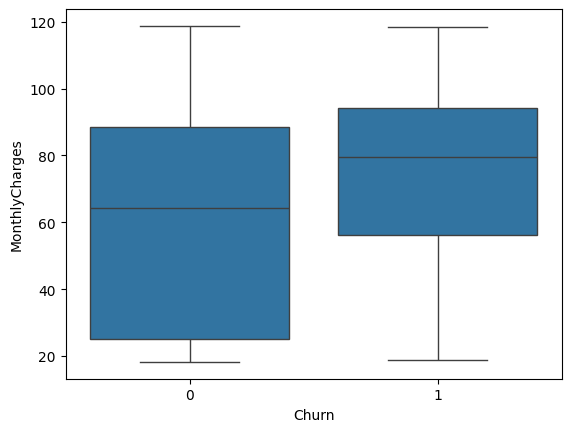

In [11]:
sns.boxplot(x = 'Churn', y = 'MonthlyCharges',data = df)
plt.show()

# Separate Feature and Target


In [12]:
x = df.drop('Churn',axis = 1)
y = df['Churn']

# Identify Numerical and categorical Columns

In [13]:
categorical_cols = x.select_dtypes(include = ['object']).columns
numerical_cols = x.select_dtypes(exclude  = ['object']).columns
print(categorical_cols)
print(numerical_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


# Create PreProcessing Pipeline

In [14]:
from sklearn.preprocessing import OneHotEncoder

In [15]:
numeric_transformer = Pipeline(steps = [
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

categorical_transformer = Pipeline(steps = [
    ('imputer',SimpleImputer(strategy = 'most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown = 'ignore'))
])

preprocessor = ColumnTransformer(transformers = [
    ('nums',numeric_transformer,numerical_cols),
    ('cat',categorical_transformer,categorical_cols)
])


# Train Test Split

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42, stratify = y)


# Random Forest Model

In [17]:
rf_model = Pipeline(steps=[
    ('Preprocessor',preprocessor),
    ('classifier',RandomForestClassifier(
        n_estimators = 200,
        max_depth = 10,
        random_state = 42
    ))
])

# Train model by Random Forest

In [18]:
rf_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nums', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [19]:
y_pred_rf = rf_model.predict(x_test)

# Accuracy by Random Forest

In [20]:
print("Accuracy : ",accuracy_score(y_test,y_pred_rf))

Accuracy :  0.8026969481902059


In [21]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



# XGBoost Model

In [22]:
xgb_model  = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',XGBClassifier(
        n_estimators = 300,
        learning_rate = 0.05,
        max_depth = 6,
        subsample= 0.8,
        colsample_bytree = 0.8,
        random_state = 42,
        eval_metric ='logloss',
    ))
])

# Train XGBoost

In [23]:
xgb_model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nums', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

# Prediction

In [24]:
y_pred_xgb = xgb_model.predict(x_test)

# Accuracy

In [25]:
print("Accuracy : ",accuracy_score(y_test,y_pred_xgb))
print(classification_report(y_test,y_pred_xgb))

Accuracy :  0.7934705464868701
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



# Confusion Matrix

In [26]:
cm = confusion_matrix(y_test,y_pred_xgb)

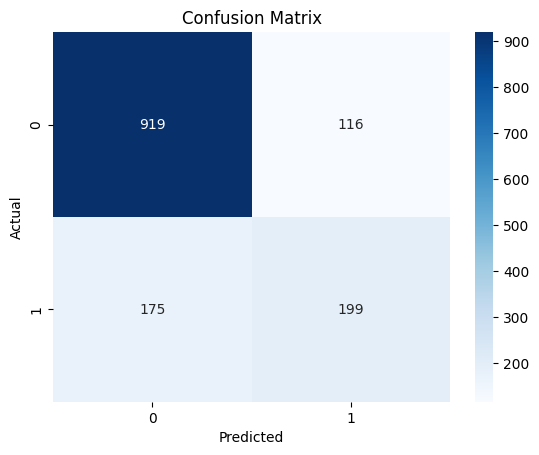

In [27]:
sns.heatmap(cm,annot = True,fmt='d',cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature Importance

In [28]:
model = xgb_model.named_steps['classifier']

feature_names = xgb_model.named_steps['preprocessor'].get_feature_names_out()

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature':feature_names,
    'Importance':importance
})

feature_importance = feature_importance.sort_values(
    by = 'Importance',ascending = False
)

print(feature_importance.head(10))

                                Feature  Importance
36         cat__Contract_Month-to-month    0.351209
16     cat__InternetService_Fiber optic    0.119318
38               cat__Contract_Two year    0.052055
18               cat__OnlineSecurity_No    0.038679
15             cat__InternetService_DSL    0.033922
27                  cat__TechSupport_No    0.033114
37               cat__Contract_One year    0.019646
35             cat__StreamingMovies_Yes    0.018747
1                          nums__tenure    0.016249
43  cat__PaymentMethod_Electronic check    0.014415


# Hyper parameter Tuning

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators':[100,200],
    'classifier__max_depth':[4,6,8],
    'classifier__learning_rate':[0.01,0.05,0.1]
}

In [30]:
grid_search = GridSearchCV(
    xgb_model,
    param_grid,
    cv = 3,
    scoring = 'accuracy',
    n_jobs = -1
)
grid_search.fit(x_train,y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)


{'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 100}
0.8061767838125666


# save the model

In [31]:
import joblib
joblib.dump(xgb_model,"churn_prediction.pkl")

['churn_prediction.pkl']

# Predicting the model 

In [32]:
single_customer = x_test.iloc[[0]]
prediction = xgb_model.predict(single_customer)

probability = xgb_model.predict_proba(single_customer)

print(prediction)
print(probability)

[0]
[[0.99739695 0.00260307]]


In [33]:
print(y_test.iloc[0])

0


In [34]:
single_customer = x_test.iloc[[0]]

prediction = xgb_model.predict(single_customer)

actual = y_test.iloc[0]

print("Predicted:", prediction[0])
print("Actual:", actual)

if prediction[0] == actual:
    print("Correct Prediction")
else:
    print("Wrong Prediction")

Predicted: 0
Actual: 0
Correct Prediction
